# Sectoral AI Intensity and Firms’ AI Sourcing Modes

**Theoretical basis:** transaction-cost economics provides the theoretical lens for examining why firms may internalise activities or obtain them externally when requirements for firm-specific knowledge and coordination increase. This pipeline uses the OECD’s independently constructed sectoral AI-intensity taxonomy as an external sector-level indicator of AI intensity. It is **not treated as a direct measure of firm-level asset specificity**; instead, the analysis tests whether differences in sectoral AI intensity are associated with firms’ AI sourcing modes.

**Purpose:** examine whether sectoral AI intensity, firm characteristics and country context are associated with how AI-adopting firms source AI across India, Nigeria, Kenya and the United States, and assess the predictive performance of machine-learning models on the same locked sample.

**Outcome:** Make, Buy, or Off-the-shelf (OTS), with OTS as the reference outcome.

**RQ1:** How is sectoral AI intensity associated with firms’ AI sourcing modes?

**RQ2:** To what extent do AI sourcing patterns differ across India, Kenya, Nigeria and the United States after accounting for sectoral AI intensity and firm characteristics?

**RQ3:** How effectively can machine-learning models predict firms’ AI sourcing modes relative to conventional statistical modelling?

The primary specification is a survey-weighted multinomial logit using the OECD sectoral AI-intensity taxonomy and World Bank Enterprise Survey follow-up weights. A machine-learning benchmark and calibration check follow as Part 2, using the same locked analysis sample.


## 1. Configuration

The notebook uses only the four thesis countries. Mexico and the earlier custom sector classification are excluded from the main pipeline because they are no longer part of the locked research design.


In [1]:
import os
import re
import shutil
import zipfile
from dataclasses import dataclass
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import patsy
from google.colab import files
from IPython.display import display
from scipy import optimize, stats

SEED = 42
np.random.seed(SEED)

COUNTRIES = ["India", "Nigeria", "Kenya", "United States"]
OUTCOME_LABELS = {1: "Make", 2: "Buy", 3: "OTS"}
CONTROLS = ["firm_size", "log_age", "exporter_any", "training", "quality_cert", "website"]
RESULTS_DIR = Path("/content/wbes_ai_results")
DATA_DIR = Path("/content/wbes_ai_data")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

## 2. Upload and identify the WBES files

Upload the baseline and 2026 AI follow-up files for India, Nigeria, Kenya, and the United States. The cell accepts either `.dta` files or the original `.zip` downloads. No Google Drive connection is required.

Files are identified from the country name and their variables rather than from an exact filename, so duplicate download suffixes such as `(1)` do not matter.


In [2]:
for path in DATA_DIR.iterdir():
    if path.is_dir():
        shutil.rmtree(path)
    else:
        path.unlink()

uploaded = files.upload()

for filename in uploaded:
    source = Path(filename)
    if source.suffix.lower() == ".zip":
        target = DATA_DIR / source.stem
        target.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(source, "r") as archive:
            archive.extractall(target)
    elif source.suffix.lower() == ".dta":
        shutil.copy2(source, DATA_DIR / source.name)

stata_files = list(DATA_DIR.rglob("*.dta"))

if not stata_files:
    raise FileNotFoundError("No Stata .dta files were found in the uploaded files.")


def normalise_name(value):
    return re.sub(r"[^a-z0-9]", "", str(value).lower())


def identify_country(path):
    name = normalise_name(path)
    if "unitedstates" in name or "usa" in name:
        return "United States"
    for country in ["India", "Nigeria", "Kenya"]:
        if normalise_name(country) in name:
            return country
    return None


candidates = []

for path in stata_files:
    frame = pd.read_stata(path, convert_categoricals=False)
    columns = set(frame.columns)
    country = identify_country(path)
    role = "followup" if "ai_b6c" in columns else "baseline" if {"idstd", "d1a2_v4", "l1", "strata"}.issubset(columns) else None
    if country in COUNTRIES and role is not None:
        candidates.append({
            "country": country,
            "role": role,
            "path": str(path),
            "rows": len(frame),
            "columns": len(frame.columns),
            "bytes": path.stat().st_size
        })

candidate_table = pd.DataFrame(candidates)

if candidate_table.empty:
    raise ValueError("The uploaded files could not be identified as the required WBES baseline or follow-up datasets.")

selected_files = (
    candidate_table.sort_values("bytes")
    .groupby(["country", "role"], as_index=False)
    .tail(1)
    .sort_values(["country", "role"])
    .reset_index(drop=True)
)

expected_pairs = {(country, role) for country in COUNTRIES for role in ["baseline", "followup"]}
found_pairs = set(zip(selected_files["country"], selected_files["role"]))
missing_pairs = expected_pairs - found_pairs

if missing_pairs:
    raise FileNotFoundError(f"Missing required country/file combinations: {sorted(missing_pairs)}")

display(selected_files[["country", "role", "rows", "columns", "path"]])

Saving WBES-OS_United States2026_Data (1).zip to WBES-OS_United States2026_Data (1).zip
Saving WBES-OS_Nigeria2026_Data (1).zip to WBES-OS_Nigeria2026_Data (1).zip
Saving WBES-OS_Mexico2026_Data (1).zip to WBES-OS_Mexico2026_Data (1).zip
Saving WBES-OS_Kenya2026_Data (1).zip to WBES-OS_Kenya2026_Data (1).zip
Saving WBES-OS_India2026_Data (1).zip to WBES-OS_India2026_Data (1).zip
Saving WBES_United States2024_Data (1).zip to WBES_United States2024_Data (1).zip
Saving WBES_Mexico2023_Data (1).zip to WBES_Mexico2023_Data (1).zip
Saving WBES_Nigeria2025_Data (1).zip to WBES_Nigeria2025_Data (1).zip
Saving WBES_Kenya2025_Data (1).zip to WBES_Kenya2025_Data (1).zip
Saving India-2025-full-data (1).zip to India-2025-full-data (1).zip


,country,role,rows,columns,path
0,India,baseline,10479,339,/content/wbes_ai_data/India-2025-full-data (1)...
1,India,followup,1355,132,/content/wbes_ai_data/WBES-OS_India2026_Data (...
2,Kenya,baseline,1024,336,/content/wbes_ai_data/WBES_Kenya2025_Data (1)/...
3,Kenya,followup,360,132,/content/wbes_ai_data/WBES-OS_Kenya2026_Data (...
4,Nigeria,baseline,1043,337,/content/wbes_ai_data/WBES_Nigeria2025_Data (1...
5,Nigeria,followup,777,131,/content/wbes_ai_data/WBES-OS_Nigeria2026_Data...
6,United States,baseline,2589,339,/content/wbes_ai_data/WBES_United States2024_D...
7,United States,followup,392,132,/content/wbes_ai_data/WBES-OS_United States202...


### Data-loading check

The table should contain exactly eight selected datasets: one baseline and one follow-up file for each country. The follow-up files are identified by the AI sourcing variable `ai_b6c`; the baseline files provide firm characteristics, survey strata, and realised ISIC Rev.4 activity.


## 3. Harmonise the firm-level data and map OECD AI intensity

Firm records are linked with `idstd`. The outcome is taken from the 2026 AI follow-up, while firm characteristics and realised ISIC Rev.4 activity come from the baseline survey.

The OECD taxonomy is mapped from two-digit ISIC Rev.4 divisions to Low, Medium, or High AI intensity. ISIC divisions 19 and 95 are outside the taxonomy used in the analysis and therefore remain unmapped.


### Provenance and independence of the OECD AI-intensity classification

The mapping below (`OECD_AI_MAP`) reproduces the sector classification published in Calvino, F., Dernis, H., Samek, L. and Ughi, A, *A Sectoral Taxonomy of AI Intensity*, OECD AI Papers No. 30, OECD Publishing, Paris. It was built by the OECD from AI patent counts, AI-related job vacancies, and AI-use survey data — entirely independent of, and published before, the WBES 2026 AI follow-up outcome data used in this thesis. No WBES variable was used in its construction. The check below is printed directly from the pipeline after the mapping is defined, so the independence claim is a verified fact, not just an assertion.


In [3]:
OECD_AI_MAP = [
    (10, 12, "Food products", "Low"),
    (13, 15, "Textiles & apparel", "Low"),
    (16, 18, "Wood & paper", "Low"),
    (20, 20, "Chemicals", "Medium"),
    (21, 21, "Pharmaceuticals", "Medium"),
    (22, 23, "Rubber, plastics, minerals", "Low"),
    (24, 25, "Metal products", "Low"),
    (26, 26, "Computer & electronics", "High"),
    (27, 27, "Electrical equipment", "Medium"),
    (28, 28, "Machinery & equipment", "Medium"),
    (29, 30, "Transport equipment", "Medium"),
    (31, 33, "Other manufactures", "Medium"),
    (41, 43, "Construction", "Low"),
    (45, 47, "Wholesale & retail", "Medium"),
    (49, 53, "Transportation & storage", "Medium"),
    (55, 56, "Hotels & food services", "Low"),
    (58, 60, "Media", "High"),
    (61, 61, "Telecommunications", "High"),
    (62, 63, "IT services", "High"),
    (64, 66, "Finance & insurance", "High"),
    (68, 68, "Real estate", "Medium"),
    (69, 71, "Legal & accounting", "High"),
    (72, 72, "Scientific R&D", "High"),
    (73, 75, "Other business services", "Medium"),
    (77, 82, "Administrative & support services", "Medium")
]


def clean_numeric(series):
    values = pd.to_numeric(series, errors="coerce")
    return values.where(values >= 0)


def yes_no(series):
    values = pd.to_numeric(series, errors="coerce")
    return values.map({1: 1.0, 2: 0.0})


def map_oecd_sector(isic2):
    if pd.isna(isic2):
        return pd.Series([np.nan, np.nan], index=["oecd_sector", "oecd_ai_intensity"])
    code = int(isic2)
    for lower, upper, sector, intensity in OECD_AI_MAP:
        if lower <= code <= upper:
            return pd.Series([sector, intensity], index=["oecd_sector", "oecd_ai_intensity"])
    return pd.Series([np.nan, np.nan], index=["oecd_sector", "oecd_ai_intensity"])


def get_path(country, role):
    return selected_files.loc[
        (selected_files["country"] == country) & (selected_files["role"] == role),
        "path"
    ].iloc[0]


def build_country_frame(country):
    followup = pd.read_stata(get_path(country, "followup"), convert_categoricals=False)
    baseline = pd.read_stata(get_path(country, "baseline"), convert_categoricals=False)

    if followup["idstd"].duplicated().any() or baseline["idstd"].duplicated().any():
        raise ValueError(f"Duplicate idstd values found for {country}.")

    followup_vars = ["idstd", "ai_b6c", "wt"]
    baseline_vars = ["idstd", "l1", "b5", "d3c", "l10", "b8", "c22b", "d1a2_v4", "strata"]

    missing_followup = [name for name in followup_vars if name not in followup.columns]
    missing_baseline = [name for name in baseline_vars if name not in baseline.columns]

    if missing_followup or missing_baseline:
        raise KeyError(f"{country}: missing follow-up variables {missing_followup}; missing baseline variables {missing_baseline}")

    followup_keep = followup_vars + (["start_year"] if "start_year" in followup.columns else [])
    merged = followup[followup_keep].merge(baseline[baseline_vars], on="idstd", how="left", validate="one_to_one")

    y = pd.to_numeric(merged["ai_b6c"], errors="coerce")
    wt = pd.to_numeric(merged["wt"], errors="coerce")
    employees = clean_numeric(merged["l1"])
    start_year = pd.to_numeric(merged["start_year"], errors="coerce") if "start_year" in merged.columns else pd.Series(2026, index=merged.index)
    start_year = start_year.where(start_year.between(2024, 2027), 2026).fillna(2026)
    start_date = clean_numeric(merged["b5"])
    firm_age = (start_year - start_date).where(lambda x: x.between(0, 200))
    export_share = clean_numeric(merged["d3c"])
    isic4 = clean_numeric(merged["d1a2_v4"])

    frame = pd.DataFrame({
        "idstd": merged["idstd"],
        "country": country,
        "y": y.where(y.isin([1, 2, 3])),
        "wt": wt.where(wt > 0),
        "firm_size": np.log(employees.where(employees > 0)),
        "log_age": np.log1p(firm_age),
        "exporter_any": (export_share > 0).astype(float).where(export_share.notna()),
        "training": yes_no(merged["l10"]),
        "quality_cert": yes_no(merged["b8"]),
        "website": yes_no(merged["c22b"]),
        "isic4": isic4,
        "isic2": np.floor(isic4 / 100),
        "stratum": country + "::" + merged["strata"].astype(str)
    })

    frame.loc[merged["strata"].isna(), "stratum"] = np.nan
    frame["sourcing_mode"] = frame["y"].map(OUTCOME_LABELS)
    mapping = frame["isic2"].apply(map_oecd_sector)
    frame = pd.concat([frame, mapping], axis=1)
    return frame


country_frames = [build_country_frame(country) for country in COUNTRIES]
wbes = pd.concat(country_frames, ignore_index=True)
wbes["oecd_ai_intensity"] = pd.Categorical(wbes["oecd_ai_intensity"], categories=["Low", "Medium", "High"], ordered=True)

valid_outcome = wbes[wbes["y"].isin([1, 2, 3])].copy()

coverage = (
    valid_outcome.groupby("country", observed=True)
    .agg(valid_sourcing_n=("y", "size"), oecd_mapped_n=("oecd_ai_intensity", lambda x: x.notna().sum()))
    .reset_index()
)
coverage["coverage_pct"] = 100 * coverage["oecd_mapped_n"] / coverage["valid_sourcing_n"]

unmapped = (
    valid_outcome[valid_outcome["oecd_ai_intensity"].isna()]
    .groupby("isic2", dropna=False)
    .size()
    .rename("n")
    .reset_index()
)

display(coverage.round(2))
display(unmapped)

,country,valid_sourcing_n,oecd_mapped_n,coverage_pct
0,India,517,517,100.00
1,Kenya,135,133,98.52
2,Nigeria,329,324,98.48
3,United States,212,212,100.00


,isic2,n
0,19.0,2
1,95.0,5


In [4]:
OECD_SOURCE_CITATION = ("Calvino, F., Dernis, H., Samek, L. and Ughi, A. (2024). "
                        "A Sectoral Taxonomy of AI Intensity. OECD AI Papers, No. 30, OECD Publishing, Paris.")
OECD_PUBLICATION_YEAR = 2024
WBES_OUTCOME_COLLECTION_YEAR = 2026

print(f"OECD sectoral AI-intensity classification source:\n  {OECD_SOURCE_CITATION}")
print(f"\nPublished {OECD_PUBLICATION_YEAR}, "
      f"{WBES_OUTCOME_COLLECTION_YEAR - OECD_PUBLICATION_YEAR} year(s) before the "
      f"{WBES_OUTCOME_COLLECTION_YEAR} WBES AI follow-up outcome data used in this thesis.")
print(f"OECD_AI_MAP covers {len(OECD_AI_MAP)} ISIC Rev.4 division ranges; no WBES variable was used in its construction.")

assert WBES_OUTCOME_COLLECTION_YEAR > OECD_PUBLICATION_YEAR, (
    "OECD classification must predate the outcome data to support the independence claim."
)
print("\n[OK] Independence check passed: classification predates outcome data collection.")

OECD sectoral AI-intensity classification source:
  Calvino, F., Dernis, H., Samek, L. and Ughi, A. (2024). A Sectoral Taxonomy of AI Intensity. OECD AI Papers, No. 30, OECD Publishing, Paris.

Published 2024, 2 year(s) before the 2026 WBES AI follow-up outcome data used in this thesis.
OECD_AI_MAP covers 25 ISIC Rev.4 division ranges; no WBES variable was used in its construction.

[OK] Independence check passed: classification predates outcome data collection.


### OECD mapping result

In the executed source pipeline, OECD mapping covered **1,186 of 1,193 valid sourcing observations across the four thesis countries (99.41%)**. The only unmapped observations were in ISIC divisions 19 and 95. This is high enough to use the OECD taxonomy without constructing an additional fallback sector measure.


## 4. Lock the common analysis sample

All primary and comparison models use one complete-case sample. This prevents changes in model results from being caused by different observations entering different specifications.

Survey weights are normalised within country so that the original within-country weighting structure is preserved without allowing the numerical scale of one country's weights to dominate the pooled likelihood.


In [5]:
required = ["y", "wt", "stratum", "country", "oecd_sector", "oecd_ai_intensity"] + CONTROLS
analysis = valid_outcome.loc[
    valid_outcome[required].notna().all(axis=1) & (valid_outcome["wt"] > 0),
    required + ["sourcing_mode", "isic2"]
].copy().reset_index(drop=True)

analysis["country"] = pd.Categorical(analysis["country"], categories=COUNTRIES)
analysis["oecd_ai_intensity"] = pd.Categorical(
    analysis["oecd_ai_intensity"].astype(str),
    categories=["Low", "Medium", "High"],
    ordered=True
)
analysis["oecd_ai_score"] = analysis["oecd_ai_intensity"].map({"Low": 0, "Medium": 1, "High": 2}).astype(float)
analysis["w_analysis"] = analysis["wt"] / analysis.groupby("country", observed=True)["wt"].transform("mean")

country_counts = analysis["country"].value_counts(sort=False).rename("n").to_frame()
intensity_counts = analysis["oecd_ai_intensity"].value_counts(sort=False).rename("n").to_frame()
country_intensity = pd.crosstab(analysis["country"], analysis["oecd_ai_intensity"])

weighted_shares = (
    analysis.groupby(["oecd_ai_intensity", "sourcing_mode"], observed=True)["w_analysis"]
    .sum()
    .rename("weighted_total")
    .reset_index()
)
weighted_shares["weighted_share"] = weighted_shares["weighted_total"] / weighted_shares.groupby("oecd_ai_intensity", observed=True)["weighted_total"].transform("sum")

display(country_counts)
display(intensity_counts)
display(country_intensity)
display(weighted_shares.pivot(index="oecd_ai_intensity", columns="sourcing_mode", values="weighted_share").round(4))

,n
country,
India,517
Nigeria,315
Kenya,131
United States,208


,n
oecd_ai_intensity,
Low,345
Medium,546
High,280


oecd_ai_intensity,Low,Medium,High
country,,,
India,69,271,177
Nigeria,169,121,25
Kenya,47,68,16
United States,60,86,62


sourcing_mode,Buy,Make,OTS
oecd_ai_intensity,,,
Low,0.1417,0.1391,0.7192
Medium,0.2734,0.1232,0.6034
High,0.4120,0.2556,0.3324


### Analysis-sample result

The executed source pipeline produced the locked complete-case sample of **N = 1,171**: India 517, Nigeria 315, Kenya 131, and the United States 208. OECD intensity groups contained 345 Low-, 546 Medium-, and 280 High-intensity observations.

These counts are the benchmark for the cleaned notebook. If they change after re-running, the uploaded source files or variable coding should be checked before interpreting the models.


## 5. Survey-weighted multinomial model

The estimator maximises a weighted multinomial pseudo-likelihood and uses OTS as the reference outcome. The primary covariance is a stratum-aware sandwich estimator. Each model is checked with multiple optimisers, and a solution is accepted from its numerical gradient rather than relying only on the optimiser's success flag.


In [6]:
@dataclass
class SurveyMultinomialResult:
    outcome: str
    formula: str
    classes: list
    reference: int
    nonreference: list
    theta: np.ndarray
    vcov: np.ndarray
    design_info: object
    design_columns: list
    weight_col: str
    strata_col: str
    n: int
    effective_n: float
    loglik: float
    converged: bool
    optimizer: str
    optimizer_message: str
    gradient_inf: float
    rank: int
    data_index: np.ndarray
    bread_inv: np.ndarray
    scores: np.ndarray

    @property
    def p(self):
        return len(self.design_columns)

    def design_matrix(self, data):
        matrix = patsy.build_design_matrices([self.design_info], data, return_type="dataframe")[0]
        return np.asarray(matrix, dtype=float)

    def predict_proba(self, data, theta=None):
        X = self.design_matrix(data)
        values = self.theta if theta is None else np.asarray(theta)
        B = values.reshape((self.p, len(self.nonreference)), order="F")
        eta = np.clip(X @ B, -40, 40)
        exp_eta = np.exp(eta)
        denominator = 1 + exp_eta.sum(axis=1, keepdims=True)
        nonreference_prob = exp_eta / denominator
        reference_prob = 1 / denominator[:, 0]
        probabilities = np.zeros((len(data), len(self.classes)))
        class_position = {value: position for position, value in enumerate(self.classes)}
        for j, value in enumerate(self.nonreference):
            probabilities[:, class_position[value]] = nonreference_prob[:, j]
        probabilities[:, class_position[self.reference]] = reference_prob
        return probabilities

    def coefficient_table(self):
        se = np.sqrt(np.clip(np.diag(self.vcov), 0, np.inf))
        z = self.theta / se
        p_values = 2 * stats.norm.sf(np.abs(z))
        lower = self.theta - 1.96 * se
        upper = self.theta + 1.96 * se
        rows = []
        position = 0
        for value in self.nonreference:
            equation = f"{OUTCOME_LABELS[value]}_vs_{OUTCOME_LABELS[self.reference]}"
            for term in self.design_columns:
                rows.append({
                    "equation": equation,
                    "term": term,
                    "coef": self.theta[position],
                    "se": se[position],
                    "p": p_values[position],
                    "RRR": np.exp(self.theta[position]),
                    "RRR_ci_low": np.exp(lower[position]),
                    "RRR_ci_high": np.exp(upper[position])
                })
                position += 1
        return pd.DataFrame(rows)

    def block_indices(self, selector):
        selected = [i for i, column in enumerate(self.design_columns) if selector(column)]
        indices = []
        for equation in range(len(self.nonreference)):
            indices.extend([equation * self.p + i for i in selected])
        return np.asarray(indices, dtype=int)

    def wald_test(self, selector, label, covariance=None):
        indices = self.block_indices(selector)
        if len(indices) == 0:
            return {"test": label, "wald": np.nan, "df": 0, "p": np.nan}
        covariance = self.vcov if covariance is None else covariance
        beta = self.theta[indices]
        variance = covariance[np.ix_(indices, indices)]
        statistic = float(beta.T @ np.linalg.pinv(variance) @ beta)
        return {"test": label, "wald": statistic, "df": len(indices), "p": float(stats.chi2.sf(statistic, len(indices)))}


def softmax_probabilities(theta, X, k):
    p = X.shape[1]
    B = theta.reshape((p, k), order="F")
    eta = np.clip(X @ B, -40, 40)
    exp_eta = np.exp(eta)
    denominator = 1 + exp_eta.sum(axis=1, keepdims=True)
    return exp_eta / denominator, 1 / denominator[:, 0]


def stratum_covariance(bread_inv, scores, strata):
    strata = pd.Series(strata).astype(str).to_numpy()
    overall_mean = scores.mean(axis=0)
    meat = np.zeros((scores.shape[1], scores.shape[1]))
    for value in pd.unique(strata):
        group_scores = scores[strata == value]
        if len(group_scores) > 1:
            centred = group_scores - group_scores.mean(axis=0, keepdims=True)
            meat += len(group_scores) / (len(group_scores) - 1) * centred.T @ centred
        else:
            centred = group_scores - overall_mean
            meat += centred.T @ centred
    covariance = bread_inv @ meat @ bread_inv
    return (covariance + covariance.T) / 2


def fit_mnlogit(data, formula, weight_col, method, maxiter=5000):
    X_frame = patsy.dmatrix(formula, data, return_type="dataframe")
    X = np.asarray(X_frame, dtype=float)
    y = data["y"].astype(int).to_numpy()
    weights = data[weight_col].astype(float).to_numpy()
    weights = weights / weights.mean()
    classes = [1, 2, 3]
    reference = 3
    nonreference = [1, 2]
    Y = np.column_stack([(y == value).astype(float) for value in nonreference])
    k = len(nonreference)
    p = X.shape[1]

    if np.linalg.matrix_rank(X) < p:
        raise np.linalg.LinAlgError("The model design matrix is rank deficient.")

    def objective(theta):
        probabilities, reference_probability = softmax_probabilities(theta, X, k)
        log_probability = np.zeros(len(y))
        for j, value in enumerate(nonreference):
            mask = y == value
            log_probability[mask] = np.log(np.clip(probabilities[mask, j], 1e-15, 1))
        mask = y == reference
        log_probability[mask] = np.log(np.clip(reference_probability[mask], 1e-15, 1))
        return -float(np.sum(weights * log_probability))

    def gradient(theta):
        probabilities, _ = softmax_probabilities(theta, X, k)
        matrix = X.T @ (weights[:, None] * (probabilities - Y))
        return matrix.reshape(-1, order="F")

    options = {"maxiter": maxiter}
    if method in ["BFGS", "CG"]:
        options["gtol"] = 1e-7
    if method == "L-BFGS-B":
        options["gtol"] = 1e-7
        options["ftol"] = 1e-12

    fitted = optimize.minimize(objective, np.zeros(p * k), jac=gradient, method=method, options=options)
    theta = fitted.x
    probabilities, _ = softmax_probabilities(theta, X, k)
    gradient_inf = float(np.max(np.abs(gradient(theta))))

    hessian = np.zeros((p * k, p * k))
    for a in range(k):
        for b in range(k):
            values = weights * ((1.0 if a == b else 0.0) * probabilities[:, a] - probabilities[:, a] * probabilities[:, b])
            block = X.T @ (X * values[:, None])
            hessian[a * p:(a + 1) * p, b * p:(b + 1) * p] = block

    bread_inv = np.linalg.pinv(hessian)
    score_blocks = [X * (weights * (Y[:, j] - probabilities[:, j]))[:, None] for j in range(k)]
    scores = np.concatenate(score_blocks, axis=1)
    vcov = stratum_covariance(bread_inv, scores, data["stratum"])
    effective_n = float(weights.sum() ** 2 / np.sum(weights ** 2))
    converged = bool(np.isfinite(fitted.fun) and gradient_inf < 1e-5)

    result = SurveyMultinomialResult(
        outcome="y",
        formula=formula,
        classes=classes,
        reference=reference,
        nonreference=nonreference,
        theta=theta,
        vcov=vcov,
        design_info=X_frame.design_info,
        design_columns=list(X_frame.columns),
        weight_col=weight_col,
        strata_col="stratum",
        n=len(data),
        effective_n=effective_n,
        loglik=-objective(theta),
        converged=converged,
        optimizer=method,
        optimizer_message=str(fitted.message),
        gradient_inf=gradient_inf,
        rank=np.linalg.matrix_rank(X),
        data_index=data.index.to_numpy(),
        bread_inv=bread_inv,
        scores=scores
    )

    diagnostic = {
        "optimizer": method,
        "scipy_success": bool(fitted.success),
        "numerical_ok": converged,
        "objective": float(fitted.fun),
        "gradient_inf": gradient_inf,
        "iterations": getattr(fitted, "nit", np.nan),
        "message": str(fitted.message)
    }
    return result, diagnostic

In [7]:
def fit_validated(data, formula, weight_col, model_name, methods=("BFGS", "L-BFGS-B", "CG")):
    results = {}
    diagnostics = []
    for method in methods:
        try:
            result, diagnostic = fit_mnlogit(data, formula, weight_col, method)
            results[method] = result
            diagnostic["model"] = model_name
            diagnostics.append(diagnostic)
        except Exception as error:
            diagnostics.append({
                "model": model_name,
                "optimizer": method,
                "scipy_success": False,
                "numerical_ok": False,
                "objective": np.nan,
                "gradient_inf": np.nan,
                "iterations": np.nan,
                "message": str(error)
            })

    audit = pd.DataFrame(diagnostics)
    valid = audit[audit["numerical_ok"] & audit["objective"].notna()]
    if valid.empty:
        valid = audit[audit["objective"].notna()]
    if valid.empty:
        raise RuntimeError(f"No valid optimiser solution was found for {model_name}.")

    best_row = valid.sort_values(["objective", "gradient_inf"]).iloc[0]
    return results[best_row["optimizer"]], best_row.to_dict(), audit


def weighted_log_loss(model, data, weight_col):
    probabilities = model.predict_proba(data)
    y = data[model.outcome].astype(int).to_numpy()
    positions = {value: position for position, value in enumerate(model.classes)}
    true_probability = np.array([probabilities[i, positions[value]] for i, value in enumerate(y)])
    weights = data[weight_col].astype(float).to_numpy()
    return -float(np.sum(weights * np.log(np.clip(true_probability, 1e-15, 1))) / np.sum(weights))

In [8]:
def standardized_probabilities(model, data, scenario_col, values, weight_col, label, eps=1e-5):
    weights = data[weight_col].astype(float).to_numpy()
    weights = weights / weights.sum()
    rows = []

    for value in values:
        scenario = data.copy()
        scenario[scenario_col] = value

        def average_probability(theta):
            probabilities = model.predict_proba(scenario, theta=theta)
            return (probabilities * weights[:, None]).sum(axis=0)

        estimate = average_probability(model.theta)
        jacobian = np.zeros((len(model.classes), len(model.theta)))

        for k in range(len(model.theta)):
            step = eps * max(1.0, abs(model.theta[k]))
            upper = model.theta.copy()
            lower = model.theta.copy()
            upper[k] += step
            lower[k] -= step
            jacobian[:, k] = (average_probability(upper) - average_probability(lower)) / (2 * step)

        covariance = jacobian @ model.vcov @ jacobian.T
        se = np.sqrt(np.clip(np.diag(covariance), 0, np.inf))

        for j, outcome in enumerate(model.classes):
            rows.append({
                "model": label,
                "scenario": value,
                "sourcing_mode": OUTCOME_LABELS[outcome],
                "probability": estimate[j],
                "se": se[j],
                "ci_low": max(0, estimate[j] - 1.96 * se[j]),
                "ci_high": min(1, estimate[j] + 1.96 * se[j])
            })

    return pd.DataFrame(rows)


def cluster_covariance(model, clusters):
    groups = pd.Series(clusters).astype(str).to_numpy()
    unique_groups = pd.unique(groups)
    meat = np.zeros((len(model.theta), len(model.theta)))

    for group in unique_groups:
        cluster_score = model.scores[groups == group].sum(axis=0)
        meat += np.outer(cluster_score, cluster_score)

    g = len(unique_groups)
    n = model.n
    q = len(model.theta)
    correction = (g / (g - 1)) * ((n - 1) / (n - q)) if g > 1 and n > q else 1.0
    covariance = correction * model.bread_inv @ meat @ model.bread_inv
    return (covariance + covariance.T) / 2


def hc1_covariance(model):
    meat = model.scores.T @ model.scores
    covariance = model.bread_inv @ meat @ model.bread_inv
    correction = model.n / (model.n - len(model.theta)) if model.n > len(model.theta) else 1.0
    covariance *= correction
    return (covariance + covariance.T) / 2

def cluster_wald_test(model, selector, label, covariance, clusters):
    indices = model.block_indices(selector)
    beta = model.theta[indices]
    variance = covariance[np.ix_(indices, indices)]
    statistic = float(beta.T @ np.linalg.pinv(variance) @ beta)
    q = len(indices)
    g = pd.Series(clusters).nunique()
    p_value = float(stats.f.sf(statistic / q, q, g - 1)) if g > 1 else np.nan
    return {"test": label, "wald": statistic, "df": q, "cluster_df": g - 1, "p": p_value}


## 6. Fit the locked models

Three models are fitted on exactly the same 1,171-firm sample:

1. Country + firm controls.
2. Country + OECD AI intensity + firm controls. This is the primary RQ1 model.
3. An ordinal Low → Medium → High trend model used only as a secondary check.

The categorical OECD specification remains primary because it does not force the distance from Low to Medium to equal the distance from Medium to High.


In [9]:
controls_rhs = " + ".join(CONTROLS)
country_term = "C(country, Treatment(reference='India'))"
intensity_term = "C(oecd_ai_intensity, Treatment(reference='Low'))"

formula_country = f"1 + {country_term} + {controls_rhs}"
formula_primary = f"1 + {country_term} + {intensity_term} + {controls_rhs}"
formula_trend = f"1 + {country_term} + oecd_ai_score + {controls_rhs}"

model_country, best_country, audit_country = fit_validated(analysis, formula_country, "w_analysis", "Country + controls")
model_primary, best_primary, audit_primary = fit_validated(analysis, formula_primary, "w_analysis", "Country + OECD intensity + controls")
model_trend, best_trend, audit_trend = fit_validated(analysis, formula_trend, "w_analysis", "Ordinal OECD trend")

optimizer_audit = pd.concat([audit_country, audit_primary, audit_trend], ignore_index=True)

selected_models = pd.DataFrame([
    {
        "model": "Country + controls",
        "optimizer": best_country["optimizer"],
        "gradient_inf": best_country["gradient_inf"],
        "effective_n": model_country.effective_n,
        "weighted_log_loss": weighted_log_loss(model_country, analysis, "w_analysis")
    },
    {
        "model": "Country + OECD intensity + controls",
        "optimizer": best_primary["optimizer"],
        "gradient_inf": best_primary["gradient_inf"],
        "effective_n": model_primary.effective_n,
        "weighted_log_loss": weighted_log_loss(model_primary, analysis, "w_analysis")
    },
    {
        "model": "Ordinal OECD trend",
        "optimizer": best_trend["optimizer"],
        "gradient_inf": best_trend["gradient_inf"],
        "effective_n": model_trend.effective_n,
        "weighted_log_loss": weighted_log_loss(model_trend, analysis, "w_analysis")
    }
])

display(selected_models.round(6))

,model,optimizer,gradient_inf,effective_n,weighted_log_loss
0,Country + controls,BFGS,0.000004,137.43995,0.915714
1,Country + OECD intensity + controls,BFGS,0.000000,137.43995,0.887588
2,Ordinal OECD trend,BFGS,0.000000,137.43995,0.893866


### Model-diagnostic result

The executed source pipeline found the same optimum across alternative optimisers. For the primary OECD model, BFGS reached a gradient of approximately **1.5 × 10⁻⁹**, supporting numerical convergence. The cleaned pipeline retains this validation but reports only the selected solution in the main output; the full optimiser audit is exported at the end.


## 7. RQ1 — sectoral AI intensity and AI sourcing modes

Transaction-cost economics provides a theoretical basis for examining whether sectoral differences in technological and task requirements are associated with firms’ sourcing choices. The OECD sectoral AI-intensity classification is used as an **external sector-level measure of AI intensity**, rather than as a direct measure of firm-level asset specificity. The primary hypothesis test is a joint Wald test of all OECD intensity coefficients across the Make-vs-OTS and Buy-vs-OTS equations. Individual relative risk ratios are interpreted only after the joint test. The analysis therefore evaluates an empirically testable association without treating sectoral AI intensity as a causal or direct proxy for an unobserved firm-level construct.


In [10]:
intensity_selector = lambda column: column.startswith("C(oecd_ai_intensity")
country_selector = lambda column: column.startswith("C(country")

primary_test = model_primary.wald_test(intensity_selector, "OECD AI intensity")
trend_test = model_trend.wald_test(lambda column: column == "oecd_ai_score", "Ordinal AI-intensity trend")
country_before_test = model_country.wald_test(country_selector, "Country before OECD intensity")
country_after_test = model_primary.wald_test(country_selector, "Country after OECD intensity")

wald_tests = pd.DataFrame([primary_test, trend_test, country_before_test, country_after_test])

coefficients = model_primary.coefficient_table()
ai_coefficients = coefficients[coefficients["term"].str.contains("oecd_ai_intensity", case=False, regex=False)].copy()
ai_coefficients["comparison"] = np.where(
    ai_coefficients["term"].str.contains("T.High", regex=False),
    "High vs Low",
    "Medium vs Low"
)
ai_coefficients = ai_coefficients[["equation", "comparison", "RRR", "RRR_ci_low", "RRR_ci_high", "p"]]

intensity_probabilities = standardized_probabilities(
    model_primary,
    analysis,
    "oecd_ai_intensity",
    ["Low", "Medium", "High"],
    "w_analysis",
    "Primary model"
)

display(wald_tests.round(6))
display(ai_coefficients.round(4))
display(
    intensity_probabilities.pivot(index="scenario", columns="sourcing_mode", values="probability")
    .reindex(["Low", "Medium", "High"])
    .round(4)
)

,test,wald,df,p
0,OECD AI intensity,18.812138,4,0.000856
1,Ordinal AI-intensity trend,11.903891,2,0.002601
2,Country before OECD intensity,17.822278,6,0.006692
3,Country after OECD intensity,14.853731,6,0.021425


,equation,comparison,RRR,RRR_ci_low,RRR_ci_high,p
4,Make_vs_OTS,Medium vs Low,0.9604,0.3928,2.3483,0.9295
5,Make_vs_OTS,High vs Low,3.8630,1.4038,10.6302,0.0089
16,Buy_vs_OTS,Medium vs Low,1.8513,0.8543,4.0116,0.1185
17,Buy_vs_OTS,High vs Low,3.9103,1.5863,9.6388,0.0031


sourcing_mode,Buy,Make,OTS
scenario,,,
Low,0.1838,0.1416,0.6745
Medium,0.2865,0.1184,0.5951
High,0.3519,0.2771,0.3711


### RQ1 result interpretation

The executed source pipeline gave a **joint Wald statistic of 18.81 (df = 4, p = 0.000856)** for categorical OECD AI intensity. This supports an association between sectoral AI intensity and AI sourcing mode after adjusting for country and firm characteristics.

Relative to Low-intensity sectors, High-intensity sectors showed an RRR of approximately **3.86 for Make vs OTS** and **3.91 for Buy vs OTS**. The adjusted probability of OTS fell from **67.5% in Low-intensity sectors to 37.1% in High-intensity sectors**, while Make and Buy became more common.

The Medium-intensity coefficients were weaker, so the main conclusion should come from the joint categorical test and adjusted probabilities rather than assuming a perfectly linear Low → Medium → High relationship.


## 8. RQ2 — country differences before and after OECD intensity adjustment

RQ2 is treated as an explanatory comparison, not a causal decomposition. The country block is tested before and after adding OECD intensity, and standardised country probabilities are compared on the same pooled covariate distribution. Adding sectoral AI intensity provides evidence on whether country contrasts change after accounting for sector composition, while any remaining country association is interpreted as residual variation rather than as a causal national effect.

The percentage change in the country Wald statistic is not interpreted as a percentage of country differences “explained”. Instead, probability gaps show how much the adjusted country contrasts become smaller or larger after sectoral AI intensity enters the model.


In [11]:
country_probabilities_before = standardized_probabilities(
    model_country,
    analysis,
    "country",
    COUNTRIES,
    "w_analysis",
    "Before OECD intensity"
)

country_probabilities_after = standardized_probabilities(
    model_primary,
    analysis,
    "country",
    COUNTRIES,
    "w_analysis",
    "After OECD intensity"
)

country_probabilities = pd.concat([country_probabilities_before, country_probabilities_after], ignore_index=True)


def probability_gap_table(before, after):
    before_table = before.pivot(index="scenario", columns="sourcing_mode", values="probability")
    after_table = after.pivot(index="scenario", columns="sourcing_mode", values="probability")
    rows = []

    for first, second in combinations(COUNTRIES, 2):
        for mode in ["Make", "Buy", "OTS"]:
            gap_before = abs(before_table.loc[first, mode] - before_table.loc[second, mode])
            gap_after = abs(after_table.loc[first, mode] - after_table.loc[second, mode])
            rows.append({
                "country_pair": f"{first} vs {second}",
                "sourcing_mode": mode,
                "gap_before": gap_before,
                "gap_after": gap_after,
                "gap_change_pp": 100 * (gap_before - gap_after)
            })

    return pd.DataFrame(rows)


country_gap_changes = probability_gap_table(country_probabilities_before, country_probabilities_after)
country_gap_summary = (
    country_gap_changes.groupby("sourcing_mode", as_index=False)
    .agg(
        mean_gap_before=("gap_before", "mean"),
        mean_gap_after=("gap_after", "mean"),
        mean_gap_change_pp=("gap_change_pp", "mean")
    )
)

display(
    country_probabilities.pivot_table(
        index=["model", "scenario"],
        columns="sourcing_mode",
        values="probability"
    ).round(4)
)
display(country_gap_changes.round(4))
display(country_gap_summary.round(4))

sourcing_mode                           Buy    Make     OTS
model                 scenario                             
After OECD intensity  India          0.4050  0.1578  0.4372
                      Kenya          0.2681  0.1844  0.5475
                      Nigeria        0.1681  0.1955  0.6364
                      United States  0.1666  0.2454  0.5880
Before OECD intensity India          0.4502  0.1799  0.3699
                      Kenya          0.2443  0.1640  0.5917
                      Nigeria        0.1486  0.1529  0.6984
                      United States  0.1488  0.2101  0.6411

,country_pair,sourcing_mode,gap_before,gap_after,gap_change_pp
0,India vs Nigeria,Make,0.0270,0.0377,-1.0795
1,India vs Nigeria,Buy,0.3016,0.2369,6.4681
2,India vs Nigeria,OTS,0.3285,0.1992,12.9379
3,India vs Kenya,Make,0.0159,0.0266,-1.0788
4,India vs Kenya,Buy,0.2059,0.1369,6.8997
5,India vs Kenya,OTS,0.2218,0.1103,11.1494
6,India vs United States,Make,0.0303,0.0876,-5.7328
7,India vs United States,Buy,0.3015,0.2384,6.3072
8,India vs United States,OTS,0.2712,0.1508,12.0399
9,Nigeria vs Kenya,Make,0.0111,0.0111,-0.0007


,sourcing_mode,mean_gap_before,mean_gap_after,mean_gap_change_pp
0,Buy,0.1667,0.1359,3.0856
1,Make,0.0312,0.0456,-1.4397
2,OTS,0.1725,0.1063,6.6174


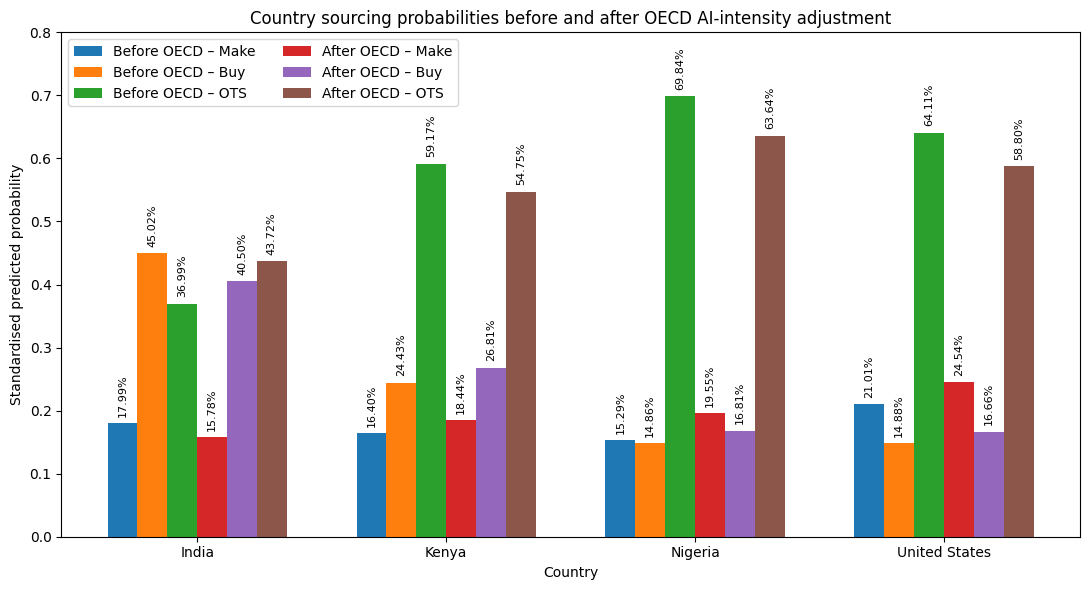

In [12]:
fig52_order = ["India", "Kenya", "Nigeria", "United States"]
fig52_modes = ["Make", "Buy", "OTS"]
fig52_models = [("Before OECD intensity", "Before OECD"), ("After OECD intensity", "After OECD")]

fig52_table = country_probabilities.pivot_table(
    index=["model", "scenario"], columns="sourcing_mode", values="probability"
)

x = np.arange(len(fig52_order))
width = 0.12
offsets = np.arange(-2.5, 3.0, 1.0) * width

fig, ax = plt.subplots(figsize=(11, 6))
position = 0
for model_label, short_label in fig52_models:
    for mode in fig52_modes:
        values = fig52_table.loc[model_label].reindex(fig52_order)[mode].to_numpy()
        bars = ax.bar(x + offsets[position], values, width, label=f"{short_label} – {mode}")
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{bar.get_height():.2%}", ha="center", va="bottom", fontsize=8, rotation=90)
        position += 1

ax.set_title("Country sourcing probabilities before and after OECD AI-intensity adjustment")
ax.set_xlabel("Country")
ax.set_ylabel("Standardised predicted probability")
ax.set_xticks(x)
ax.set_xticklabels(fig52_order)
ax.set_ylim(0, 0.80)
ax.legend(ncol=2, loc="upper left")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figure_5_2_country_probabilities.png", dpi=300, bbox_inches="tight")
plt.show()

### RQ2 result interpretation

In the executed source pipeline, the joint country Wald statistic changed from **17.82 (p = 0.0067)** before OECD intensity was added to **14.85 (p = 0.0214)** afterward. Country differences therefore remained statistically detectable after sectoral AI intensity was controlled for.

The final RQ2 interpretation should use the standardized probability-gap tables produced above. A positive `gap_change_pp` means the corresponding country gap became smaller after OECD intensity was added; a negative value means it became larger. This provides an interpretable measure of attenuation without describing the Wald-statistic change as a percentage "explained."


## 9. Robustness checks

The primary result is checked against three alternative weighting choices and two alternative covariance estimators. Equal-country weighting limits the influence of countries with larger survey-weight totals, unweighted estimation removes survey weights, and 99th-percentile trimming limits unusually large weights.

The sector-clustered covariance is particularly important because OECD AI intensity is assigned at the sector level. It allows observations in the same OECD sector to share unobserved disturbances.


In [13]:
analysis["w_equal_country"] = analysis.groupby("country", observed=True)["wt"].transform(lambda x: x / x.sum())
analysis["w_equal_country"] = analysis["w_equal_country"] / analysis["w_equal_country"].mean()
analysis["w_unweighted"] = 1.0
analysis["wt_trim99"] = analysis.groupby("country", observed=True)["wt"].transform(lambda x: x.clip(upper=x.quantile(0.99)))
analysis["w_trim99"] = analysis["wt_trim99"] / analysis.groupby("country", observed=True)["wt_trim99"].transform("mean")

weight_specs = {
    "Primary survey weights": "w_analysis",
    "Equal-country weights": "w_equal_country",
    "Unweighted": "w_unweighted",
    "99% trimmed survey weights": "w_trim99"
}

weight_models = {"Primary survey weights": model_primary}
weight_rows = []

for label, weight_col in weight_specs.items():
    if label == "Primary survey weights":
        model = model_primary
        best = best_primary
    else:
        model, best, _ = fit_validated(
            analysis,
            formula_primary,
            weight_col,
            label,
            methods=("BFGS", "L-BFGS-B")
        )
        weight_models[label] = model

    test = model.wald_test(intensity_selector, "OECD AI intensity")
    table = model.coefficient_table()
    high_make = table[(table["equation"] == "Make_vs_OTS") & table["term"].str.contains("T.High", regex=False)].iloc[0]
    high_buy = table[(table["equation"] == "Buy_vs_OTS") & table["term"].str.contains("T.High", regex=False)].iloc[0]

    weight_rows.append({
        "specification": label,
        "effective_n": model.effective_n,
        "optimizer": best["optimizer"],
        "AI_wald": test["wald"],
        "AI_p": test["p"],
        "High_Make_vs_OTS_RRR": high_make["RRR"],
        "High_Make_p": high_make["p"],
        "High_Buy_vs_OTS_RRR": high_buy["RRR"],
        "High_Buy_p": high_buy["p"]
    })

weight_robustness = pd.DataFrame(weight_rows)

sector_vcov = cluster_covariance(model_primary, analysis["oecd_sector"])
hc1_vcov = hc1_covariance(model_primary)

primary_inference = model_primary.wald_test(intensity_selector, "Primary stratum-aware sandwich")
primary_inference["cluster_df"] = np.nan
hc1_inference = model_primary.wald_test(intensity_selector, "HC1 firm-level sandwich", covariance=hc1_vcov)
hc1_inference["cluster_df"] = np.nan
sector_inference = cluster_wald_test(
    model_primary,
    intensity_selector,
    "OECD-sector clustered sandwich",
    sector_vcov,
    analysis["oecd_sector"]
)

inference_robustness = pd.DataFrame([primary_inference, sector_inference, hc1_inference])

display(weight_robustness.round(6))
display(inference_robustness.round(6))

,specification,effective_n,optimizer,AI_wald,AI_p,High_Make_vs_OTS_RRR,High_Make_p,High_Buy_vs_OTS_RRR,High_Buy_p
0,Primary survey weights,137.439950,BFGS,18.812138,0.000856,3.862987,0.008877,3.910266,0.003052
1,Equal-country weights,196.127839,BFGS,13.001332,0.011269,2.228420,0.160738,2.717593,0.021687
2,Unweighted,1171.000000,BFGS,30.446924,0.000004,3.664091,0.000000,1.853210,0.005725
3,99% trimmed survey weights,249.725414,BFGS,24.536423,0.000062,4.392203,0.001605,3.718792,0.000570


,test,wald,df,p,cluster_df
0,Primary stratum-aware sandwich,18.812138,4,0.000856,NaN
1,OECD-sector clustered sandwich,47.527190,4,0.000027,22.0
2,HC1 firm-level sandwich,18.326125,4,0.001066,NaN


### Robustness interpretation

In the executed source pipeline, the categorical OECD intensity block remained statistically significant under the original survey weights, equal-country weights, unweighted estimation, and 99% weight trimming. The High-intensity Buy-vs-OTS association was the most stable individual contrast; the High-intensity Make-vs-OTS coefficient was less stable under equal-country weighting.

The sector-clustered result in the cleaned pipeline should be reported alongside the primary stratum-aware covariance because the explanatory variable is defined at the sector level. If this check materially changes the inference, that difference should be discussed rather than hidden.


## 10. Primary figure

The figure reports standardized sourcing probabilities from the primary model while holding the pooled firm and country composition constant.


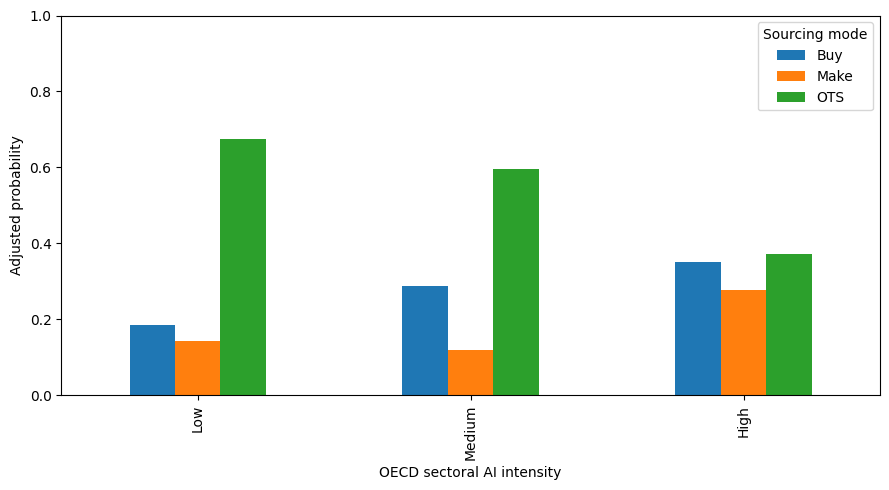

In [14]:
plot_data = (
    intensity_probabilities.pivot(index="scenario", columns="sourcing_mode", values="probability")
    .reindex(["Low", "Medium", "High"])
)

ax = plot_data.plot(kind="bar", figsize=(9, 5))
ax.set_xlabel("OECD sectoral AI intensity")
ax.set_ylabel("Adjusted probability")
ax.set_ylim(0, 1)
ax.legend(title="Sourcing mode")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "adjusted_probabilities_by_ai_intensity.png", dpi=300, bbox_inches="tight")
plt.show()

### Figure interpretation

The expected pattern from the executed source pipeline is a marked decline in OTS use as sectoral AI intensity moves from Low to High, accompanied by higher adjusted probabilities of Make and Buy. The figure should be used as the main substantive presentation of RQ1 because probabilities are easier to interpret than multinomial log-odds.


## 11. Export thesis-ready outputs

Only outputs directly connected to the locked research questions and robustness checks are exported. The full optimiser audit is saved for reproducibility but does not need to appear in the main dissertation results chapter.


In [15]:
exports = {
    "oecd_mapping_coverage.csv": coverage,
    "analysis_country_counts.csv": country_counts.reset_index(),
    "analysis_intensity_counts.csv": intensity_counts.reset_index(),
    "wald_tests.csv": wald_tests,
    "oecd_ai_coefficients.csv": ai_coefficients,
    "adjusted_probabilities_by_ai_intensity.csv": intensity_probabilities,
    "country_probabilities_before_after_oecd.csv": country_probabilities,
    "country_probability_gap_changes.csv": country_gap_changes,
    "country_probability_gap_summary.csv": country_gap_summary,
    "weight_robustness.csv": weight_robustness,
    "inference_robustness.csv": inference_robustness,
    "optimizer_audit.csv": optimizer_audit
}

for filename, table in exports.items():
    table.to_csv(RESULTS_DIR / filename, index=False)

archive_path = shutil.make_archive("/content/wbes_ai_results", "zip", RESULTS_DIR)

print(f"Results folder: {RESULTS_DIR}")
print(f"ZIP archive: {archive_path}")

Results folder: /content/wbes_ai_results
ZIP archive: /content/wbes_ai_results.zip


## 12. Final pipeline scope

This pipeline answers three locked research questions. RQ1 examines the association between sectoral AI intensity and AI sourcing modes using a survey-weighted multinomial logit. RQ2 examines country differences before and after accounting for sectoral AI intensity and firm characteristics. RQ3 evaluates machine-learning classification performance relative to conventional statistical modelling on the identical locked sample, with calibration treated as an additional predictive diagnostic.

The earlier India-only primary model, Make-vs-Buy boundary model, custom Manufacturing / Knowledge-intensive-digital / Other sector variable, Mexico analysis, and cross-country transferability experiment are not included because they are not required to answer RQ1–RQ3 and would make the main analytical pipeline harder to defend. If needed for context, they belong in a separate exploratory or appendix notebook.


## 13. Part 2 — machine learning benchmark (RQ3)

Same locked sample as RQ1/RQ2 (the same rows, same survey weights, same `country` and `CONTROLS` variables), so the statistical and machine-learning results are directly comparable. Four models are compared: a majority-class baseline, tuned logistic regression, tuned random forest, and tuned gradient boosting. Hyperparameters are selected by a small randomised search on an *inner* cross-validation split that never touches the outer evaluation fold, so the reported score is a genuine held-out estimate rather than one inflated by tuning on the same rows it is scored on.


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, ParameterSampler
from sklearn.metrics import balanced_accuracy_score, log_loss

ml_frame = analysis[["y", "w_analysis", "country"] + CONTROLS + ["oecd_ai_score"]].copy()
ml_numeric = CONTROLS + ["oecd_ai_score"]
ml_categorical = ["country"]


def build_preprocessor(numeric_cols, categorical_cols, scale_numeric):
    steps = []
    if numeric_cols:
        steps.append(("numeric", StandardScaler() if scale_numeric else "passthrough", numeric_cols))
    if categorical_cols:
        steps.append(("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols))
    return ColumnTransformer(steps)


MODEL_LIBRARY = {
    "majority_baseline": {"build": lambda p: DummyClassifier(strategy="prior"), "grid": {}, "scale": False},
    "logistic_regression": {"build": lambda p: LogisticRegression(max_iter=5000, **p),
                            "grid": {"C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]}, "scale": True},
    "random_forest": {"build": lambda p: RandomForestClassifier(random_state=SEED, **p),
                      "grid": {"n_estimators": [100, 200, 300], "max_depth": [3, 4, 6, None], "min_samples_leaf": [1, 3, 5]}, "scale": False},
    "gradient_boosting": {"build": lambda p: HistGradientBoostingClassifier(random_state=SEED, **p),
                          "grid": {"max_depth": [2, 3, 4], "max_iter": [100, 200, 300], "learning_rate": [0.03, 0.06, 0.1]}, "scale": False},
}


def make_pipeline(model_name, params, numeric_cols, categorical_cols):
    spec = MODEL_LIBRARY[model_name]
    return Pipeline([("preprocess", build_preprocessor(numeric_cols, categorical_cols, spec["scale"])),
                     ("classify", spec["build"](params))])


def fit_and_score(model_name, params, train_frame, test_frame, numeric_cols, categorical_cols):
    pipeline = make_pipeline(model_name, params, numeric_cols, categorical_cols)
    feature_cols = numeric_cols + categorical_cols
    pipeline.fit(train_frame[feature_cols], train_frame["y"], classify__sample_weight=train_frame["w_analysis"].to_numpy())
    probabilities = pipeline.predict_proba(test_frame[feature_cols])
    predictions = np.array(pipeline.classes_)[probabilities.argmax(axis=1)]
    score = balanced_accuracy_score(test_frame["y"], predictions, sample_weight=test_frame["w_analysis"].to_numpy())
    return score, predictions, probabilities, pipeline.classes_


def tune_hyperparameters(model_name, train_frame, numeric_cols, categorical_cols, seed, n_candidates=6, inner_folds=3):
    grid = MODEL_LIBRARY[model_name]["grid"]
    if not grid:
        return {}
    candidates = list(ParameterSampler(grid, n_iter=n_candidates, random_state=seed))
    splitter = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=seed)
    best_params, best_score = {}, -np.inf
    for params in candidates:
        scores = []
        for train_idx, test_idx in splitter.split(train_frame, train_frame["y"]):
            score, *_ = fit_and_score(model_name, params, train_frame.iloc[train_idx], train_frame.iloc[test_idx], numeric_cols, categorical_cols)
            scores.append(score)
        if np.mean(scores) > best_score:
            best_params, best_score = params, np.mean(scores)
    return best_params


BENCHMARK_SEEDS = [SEED, SEED + 1, SEED + 2]
benchmark_rows, oof_records = [], []

for seed in BENCHMARK_SEEDS:
    outer_splitter = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=seed)
    for fold_id, (train_idx, test_idx) in enumerate(outer_splitter.split(ml_frame, ml_frame["y"])):
        train_frame = ml_frame.iloc[train_idx]
        test_frame = ml_frame.iloc[test_idx]
        for model_name in MODEL_LIBRARY:
            best_params = tune_hyperparameters(model_name, train_frame, ml_numeric, ml_categorical, seed)
            score, predictions, probabilities, classes = fit_and_score(model_name, best_params, train_frame, test_frame, ml_numeric, ml_categorical)
            fold_loss = log_loss(test_frame["y"], probabilities, sample_weight=test_frame["w_analysis"].to_numpy(), labels=list(classes))
            benchmark_rows.append({"model": model_name, "seed": seed, "fold": fold_id, "balanced_accuracy": score, "log_loss": fold_loss})
            for position, row_index in enumerate(test_frame.index):
                probs_by_class = dict(zip(classes, probabilities[position]))
                oof_records.append({
                    "model": model_name, "row_index": row_index,
                    "y_true": test_frame["y"].iloc[position], "y_pred": predictions[position],
                    "weight": test_frame["w_analysis"].iloc[position],
                    "p_make": probs_by_class.get(1, 0.0), "p_buy": probs_by_class.get(2, 0.0), "p_ots": probs_by_class.get(3, 0.0),
                })

benchmark_results = pd.DataFrame(benchmark_rows)
oof_predictions = pd.DataFrame(oof_records)
print(f"Benchmark complete: {len(benchmark_results)} model-fold evaluations on the same {len(ml_frame)}-firm locked sample used for RQ1/RQ2.")


Benchmark complete: 180 model-fold evaluations on the same 1171-firm locked sample used for RQ1/RQ2.


### Comparing the models

Mean weighted balanced accuracy and log loss per model, then a corrected paired t-test (Nadeau and Bengio, 2003) of each model against the logistic-regression baseline. The correction matters: outer folds share rows with each other, so a plain t-test would overstate how confident the comparison can be.


In [17]:
from scipy import stats as sp_stats


def corrected_resampled_ttest(score_a, score_b, n_train, n_test):
    difference = score_a - score_b
    variance = difference.var(ddof=1)
    correction = (1.0 / len(difference)) + (n_test / n_train)
    standard_error = np.sqrt(variance * correction) if variance > 0 else np.nan
    if standard_error > 0:
        t_statistic = difference.mean() / standard_error
        p_value = 2 * sp_stats.t.sf(abs(t_statistic), len(difference) - 1)
    else:
        t_statistic, p_value = np.nan, np.nan
    return difference.mean(), t_statistic, p_value


ml_summary = (benchmark_results.groupby("model")
             .agg(balanced_accuracy_mean=("balanced_accuracy", "mean"),
                  balanced_accuracy_std=("balanced_accuracy", "std"),
                  log_loss_mean=("log_loss", "mean"))
             .sort_values("balanced_accuracy_mean", ascending=False).reset_index())

n_test_rows = len(ml_frame) // 5
n_train_rows = len(ml_frame) - n_test_rows
baseline_scores = benchmark_results[benchmark_results["model"] == "logistic_regression"].sort_values(["seed", "fold"])["balanced_accuracy"].to_numpy()

comparison_rows = []
for model_name in MODEL_LIBRARY:
    if model_name == "logistic_regression":
        continue
    challenger_scores = benchmark_results[benchmark_results["model"] == model_name].sort_values(["seed", "fold"])["balanced_accuracy"].to_numpy()
    mean_gain, t_stat, p_value = corrected_resampled_ttest(challenger_scores, baseline_scores, n_train_rows, n_test_rows)
    comparison_rows.append({"model": model_name, "mean_gain_over_logistic": mean_gain, "t_statistic": t_stat, "p_value": p_value})

ml_vs_logistic = pd.DataFrame(comparison_rows)
winning_model = ml_summary.iloc[0]["model"]

display(ml_summary.round(4))
display(ml_vs_logistic.round(4))
print(f"Highest weighted balanced accuracy: {winning_model}. Check ml_vs_logistic for whether that edge is statistically real.")


,model,balanced_accuracy_mean,balanced_accuracy_std,log_loss_mean
0,gradient_boosting,0.4233,0.0782,1.1449
1,random_forest,0.4123,0.0682,0.9434
2,logistic_regression,0.4056,0.0669,1.0322
3,majority_baseline,0.3333,0.0000,1.0111


,model,mean_gain_over_logistic,t_statistic,p_value
0,majority_baseline,-0.0723,-2.0704,0.0443
1,random_forest,0.0067,0.3204,0.7502
2,gradient_boosting,0.0177,0.4264,0.6719


Highest weighted balanced accuracy: gradient_boosting. Check ml_vs_logistic for whether that edge is statistically real.


## 14. Is the winning model's confidence trustworthy?

Balanced accuracy alone cannot distinguish a model that is honestly uncertain from one that is confidently wrong. Expected calibration error, mean confidence versus actual weighted accuracy, and a reliability diagram for the top-scoring model, all computed on genuinely out-of-fold predictions collected during the benchmark above.


,model,expected_calibration_error,mean_confidence,weighted_accuracy
0,majority_baseline,0.0197,0.5371,0.5348
1,random_forest,0.0490,0.6045,0.5617
2,logistic_regression,0.0732,0.5924,0.5393
3,gradient_boosting,0.1677,0.7027,0.5403


Overconfident models (stated confidence exceeds actual accuracy by >5pp): ['logistic_regression', 'gradient_boosting']


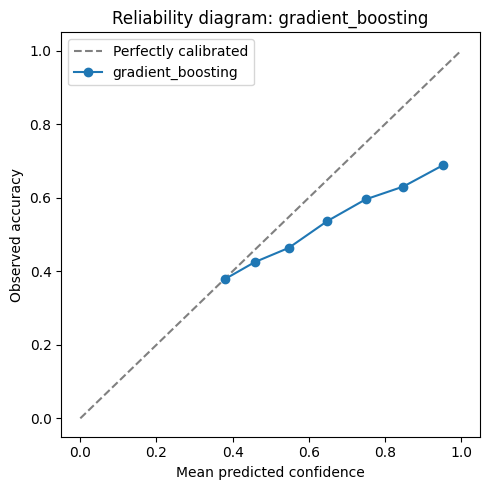

ML benchmark, significance test, and calibration results exported alongside the RQ1/RQ2 outputs.


In [18]:
def expected_calibration_error(confidence, is_correct, weight, n_bins=10):
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_id = np.digitize(confidence, bin_edges[1:-1])
    total_weight = weight.sum()
    error = 0.0
    for bin_index in range(n_bins):
        in_bin = bin_id == bin_index
        if not in_bin.any():
            continue
        bin_weight_share = weight[in_bin].sum() / total_weight
        bin_confidence = np.average(confidence[in_bin], weights=weight[in_bin])
        bin_accuracy = np.average(is_correct[in_bin], weights=weight[in_bin])
        error += bin_weight_share * abs(bin_accuracy - bin_confidence)
    return error


calibration_rows = []
for model_name, group in oof_predictions.groupby("model"):
    confidence = group[["p_make", "p_buy", "p_ots"]].max(axis=1).to_numpy()
    is_correct = (group["y_true"] == group["y_pred"]).to_numpy().astype(float)
    weight = group["weight"].to_numpy()
    calibration_rows.append({
        "model": model_name,
        "expected_calibration_error": expected_calibration_error(confidence, is_correct, weight),
        "mean_confidence": float(np.average(confidence, weights=weight)),
        "weighted_accuracy": float(np.average(is_correct, weights=weight)),
    })

calibration_summary = pd.DataFrame(calibration_rows).sort_values("expected_calibration_error").reset_index(drop=True)
display(calibration_summary.round(4))

overconfident = calibration_summary[calibration_summary["mean_confidence"] > calibration_summary["weighted_accuracy"] + 0.05]
if len(overconfident):
    print(f"Overconfident models (stated confidence exceeds actual accuracy by >5pp): {overconfident['model'].tolist()}")

best_group = oof_predictions[oof_predictions["model"] == winning_model]
confidence = best_group[["p_make", "p_buy", "p_ots"]].max(axis=1).to_numpy()
is_correct = (best_group["y_true"] == best_group["y_pred"]).to_numpy().astype(float)
bin_edges = np.linspace(0.0, 1.0, 11)
bin_id = np.digitize(confidence, bin_edges[1:-1])
bin_conf, bin_acc = [], []
for bin_index in range(10):
    in_bin = bin_id == bin_index
    if in_bin.sum() < 3:
        continue
    bin_conf.append(confidence[in_bin].mean())
    bin_acc.append(is_correct[in_bin].mean())

ax = plt.figure(figsize=(5, 5)).gca()
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfectly calibrated")
ax.plot(bin_conf, bin_acc, marker="o", label=winning_model)
ax.set_xlabel("Mean predicted confidence")
ax.set_ylabel("Observed accuracy")
ax.set_title(f"Reliability diagram: {winning_model}")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ml_reliability_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

ml_summary.to_csv(RESULTS_DIR / "ml_benchmark_summary.csv", index=False)
ml_vs_logistic.to_csv(RESULTS_DIR / "ml_vs_logistic_significance.csv", index=False)
calibration_summary.to_csv(RESULTS_DIR / "ml_calibration_summary.csv", index=False)
print("ML benchmark, significance test, and calibration results exported alongside the RQ1/RQ2 outputs.")


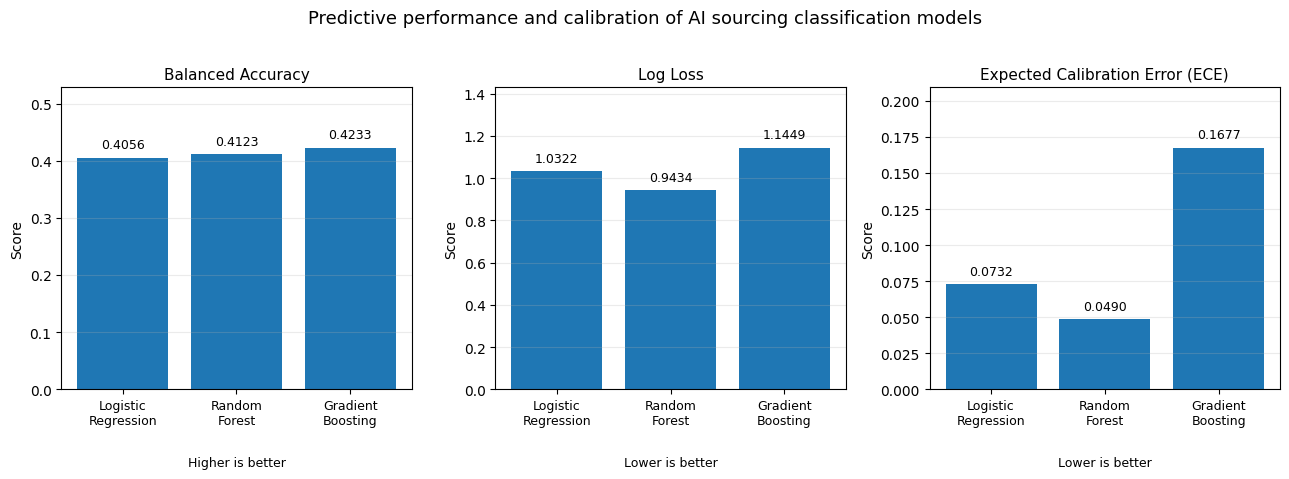

In [19]:
fig53_models = ["logistic_regression", "random_forest", "gradient_boosting"]
fig53_labels = ["Logistic\nRegression", "Random\nForest", "Gradient\nBoosting"]

fig53_data = (
    ml_summary.set_index("model")[["balanced_accuracy_mean", "log_loss_mean"]]
    .join(calibration_summary.set_index("model")[["expected_calibration_error"]])
    .loc[fig53_models]
)

panels = [
    ("Balanced Accuracy", "balanced_accuracy_mean", "Higher is better"),
    ("Log Loss", "log_loss_mean", "Lower is better"),
    ("Expected Calibration Error (ECE)", "expected_calibration_error", "Lower is better"),
]

x = np.arange(len(fig53_models))
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))
for ax, (title, column, note) in zip(axes, panels):
    values = fig53_data[column].to_numpy()
    bars = ax.bar(x, values)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(fig53_labels, fontsize=9)
    ax.set_ylabel("Score")
    ax.set_ylim(0, values.max() * 1.25)
    ax.grid(axis="y", alpha=0.25)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + values.max() * 0.025,
                f"{value:.4f}", ha="center", va="bottom", fontsize=9)
    ax.text(0.5, -0.22, note, transform=ax.transAxes, ha="center", va="top", fontsize=9)

fig.suptitle("Predictive performance and calibration of AI sourcing classification models", fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig(RESULTS_DIR / "figure_5_3_ml_performance_calibration.png", dpi=300, bbox_inches="tight")
plt.show()